# Regresión y factores asociados a la felicidad

## Objetivo
Analizar la relación entre felicidad y producto interno bruto (GDP) y comparar una regresión lineal simple con una regresión múltiple que incorpora indicadores sociales y de salud.

## Datos
El conjunto inicial contiene 141 países con felicidad y GDP. Para el modelo múltiple se integran indicadores de esperanza de vida, desempleo y uso de Internet mediante World Bank Open Data.

## Metodología
Se exploran los datos, se aplica una transformación logarítmica al GDP, se ajusta una regresión lineal simple y después una regresión lineal múltiple. Los modelos se comparan mediante R² y R² ajustado.


In [1]:
import pandas as pd

datos = pd.read_csv("A1.2 Felicidad y GDP.csv")

print(datos.head())
print("\nCantidad de filas y columnas:", datos.shape)
print("\nColumnas:", datos.columns.tolist())

          Pais  Felicidad           GDP
0      Finland     7.8210  2.718370e+11
1      Denmark     7.6362  3.560850e+11
2      Iceland     7.5575  2.171808e+10
3  Switzerland     7.5116  7.522480e+11
4  Netherlands     7.4149  9.138650e+11

Cantidad de filas y columnas: (141, 3)

Columnas: ['Pais', 'Felicidad', 'GDP']


In [2]:
print(datos.info())

print("\nValores faltantes:")
print(datos.isnull().sum())

print("\nEstadísticas principales:")
print(datos[["Felicidad", "GDP"]].describe())

<class 'pandas.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Pais       141 non-null    str    
 1   Felicidad  141 non-null    float64
 2   GDP        141 non-null    float64
dtypes: float64(2), str(1)
memory usage: 3.4 KB
None

Valores faltantes:
Pais         0
Felicidad    0
GDP          0
dtype: int64

Estadísticas principales:
        Felicidad           GDP
count  141.000000  1.410000e+02
mean     5.560004  5.889942e+11
std      1.098011  2.221612e+12
min      2.403800  1.223876e+09
25%      4.887900  1.805117e+10
50%      5.585300  6.215800e+10
75%      6.309100  3.452960e+11
max      7.821000  2.089370e+13


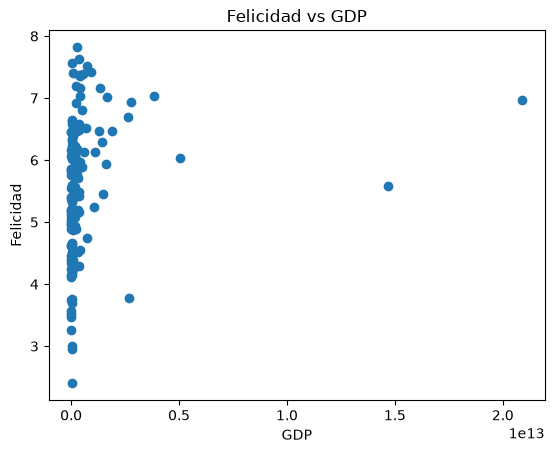

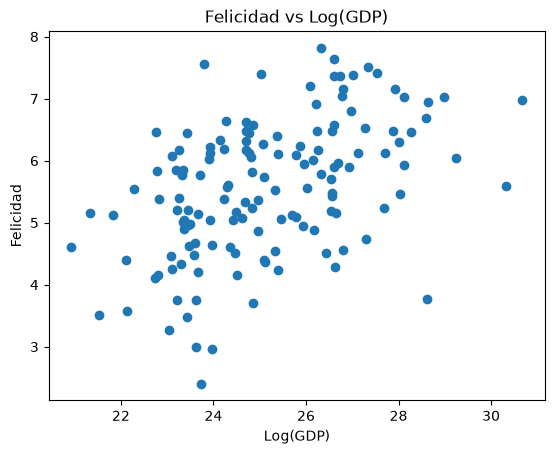

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Grafica con GDP original
plt.scatter(datos["GDP"], datos["Felicidad"])
plt.xlabel("GDP")
plt.ylabel("Felicidad")
plt.title("Felicidad vs GDP")
plt.show()

# Crear logaritmo del GDP
datos["Log_GDP"] = np.log(datos["GDP"])

# Grafica con GDP transformado
plt.scatter(datos["Log_GDP"], datos["Felicidad"])
plt.xlabel("Log(GDP)")
plt.ylabel("Felicidad")
plt.title("Felicidad vs Log(GDP)")
plt.show()

In [4]:
import statsmodels.api as sm

X = datos["Log_GDP"]
y = datos["Felicidad"]

X = sm.add_constant(X)

modelo_simple = sm.OLS(y, X).fit()

print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:              Felicidad   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     39.59
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           3.83e-09
Time:                        10:02:02   Log-Likelihood:                -195.09
No. Observations:                 141   AIC:                             394.2
Df Residuals:                     139   BIC:                             400.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3024      1.094     -1.191      0.2

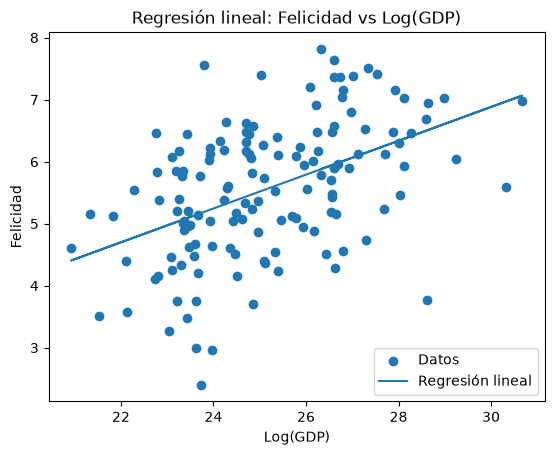

In [5]:
plt.scatter(datos["Log_GDP"], datos["Felicidad"], label="Datos")

plt.plot(
    datos["Log_GDP"],
    modelo_simple.predict(X),
    label="Regresión lineal"
)

plt.xlabel("Log(GDP)")
plt.ylabel("Felicidad")
plt.title("Regresión lineal: Felicidad vs Log(GDP)")
plt.legend()
plt.show()

In [6]:
import urllib.request
import json

def obtener_datos(codigo, nombre):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{codigo}?date=2020&format=json&per_page=400"
    
    with urllib.request.urlopen(url) as respuesta:
        contenido = json.loads(respuesta.read().decode())
    
    lista = []

    for dato in contenido[1]:
        if dato["value"] is not None:
            lista.append({
                "Pais": dato["country"]["value"],
                nombre: dato["value"]
            })

    return pd.DataFrame(lista)

esperanza = obtener_datos("SP.DYN.LE00.IN", "Esperanza_Vida")
desempleo = obtener_datos("SL.UEM.TOTL.ZS", "Desempleo")
internet = obtener_datos("IT.NET.USER.ZS", "Internet")

print("Esperanza de vida:", esperanza.shape)
print("Desempleo:", desempleo.shape)
print("Internet:", internet.shape)

Esperanza de vida: (264, 2)
Desempleo: (234, 2)
Internet: (216, 2)


In [7]:
datos_completos = datos.merge(esperanza, on="Pais", how="inner")
datos_completos = datos_completos.merge(desempleo, on="Pais", how="inner")
datos_completos = datos_completos.merge(internet, on="Pais", how="inner")

print("Países originales:", len(datos))
print("Países con información completa:", len(datos_completos))

print("\nColumnas:")
print(datos_completos.columns.tolist())

print("\nPrimeros datos:")
print(datos_completos.head())

Países originales: 141
Países con información completa: 126

Columnas:
['Pais', 'Felicidad', 'GDP', 'Log_GDP', 'Esperanza_Vida', 'Desempleo', 'Internet']

Primeros datos:
          Pais  Felicidad           GDP    Log_GDP  Esperanza_Vida  Desempleo  \
0      Finland     7.8210  2.718370e+11  26.328468       81.931707      7.759   
1      Denmark     7.6362  3.560850e+11  26.598435       81.602439      5.644   
2      Iceland     7.5575  2.171808e+10  23.801411       83.063415      5.478   
3  Switzerland     7.5116  7.522480e+11  27.346332       83.000000      4.817   
4  Netherlands     7.4149  9.138650e+11  27.540949       81.358537      3.820   

    Internet  
0  92.170271  
1  96.549146  
2  99.532752  
3  94.349998  
4  91.333333  


In [8]:
X_multiple = datos_completos[
    ["Log_GDP", "Esperanza_Vida", "Desempleo", "Internet"]
]

y_multiple = datos_completos["Felicidad"]

X_multiple = sm.add_constant(X_multiple)

modelo_multiple = sm.OLS(y_multiple, X_multiple).fit()

print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:              Felicidad   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     69.02
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           2.57e-30
Time:                        10:12:58   Log-Likelihood:                -119.62
No. Observations:                 126   AIC:                             249.2
Df Residuals:                     121   BIC:                             263.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3323      1.091      0.

In [9]:
X_simple_126 = sm.add_constant(datos_completos["Log_GDP"])
y_simple_126 = datos_completos["Felicidad"]

modelo_simple_126 = sm.OLS(y_simple_126, X_simple_126).fit()

print("COMPARACION DE MODELOS")
print("----------------------")
print("Modelo simple")
print("R2:", round(modelo_simple_126.rsquared, 3))
print("R2 ajustado:", round(modelo_simple_126.rsquared_adj, 3))

print("\nModelo multiple")
print("R2:", round(modelo_multiple.rsquared, 3))
print("R2 ajustado:", round(modelo_multiple.rsquared_adj, 3))

COMPARACION DE MODELOS
----------------------
Modelo simple
R2: 0.27
R2 ajustado: 0.264

Modelo multiple
R2: 0.695
R2 ajustado: 0.685


In [10]:
comparacion = pd.DataFrame({
    "Modelo": ["Regresión simple", "Regresión múltiple"],
    "R2": [
        round(modelo_simple_126.rsquared, 3),
        round(modelo_multiple.rsquared, 3)
    ],
    "R2 ajustado": [
        round(modelo_simple_126.rsquared_adj, 3),
        round(modelo_multiple.rsquared_adj, 3)
    ],
    "Numero de paises": [126, 126]
})

print(comparacion)

               Modelo     R2  R2 ajustado  Numero de paises
0    Regresión simple  0.270        0.264               126
1  Regresión múltiple  0.695        0.685               126


## Conclusiones
El modelo simple muestra una relación positiva entre Log(GDP) y felicidad, pero su capacidad explicativa es limitada. Al incorporar esperanza de vida, desempleo y uso de Internet, el modelo múltiple mejora considerablemente el R², lo que sugiere que la felicidad está asociada con factores económicos, sociales y de salud.

## Fuentes de datos
- World Happiness Report 2022.
- World Bank Open Data: esperanza de vida, desempleo y uso de Internet.
